In [29]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import pandas as pd
import scipy


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [30]:
# --- Simulation config ---
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000           # number of time steps
DT = T_HORIZON / (T)   # fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [31]:
# --- Data generation ---

translator = {
    'I': 'Current [A]',
    'V': 'Terminal voltage [V]',
    'cn': 'X-averaged negative particle concentration [mol.m-3]',
    'cp': 'X-averaged positive particle concentration [mol.m-3]',
    'cns': 'X-averaged negative particle surface concentration [mol.m-3]',
    'cps': 'X-averaged positive particle surface concentration [mol.m-3]',
    'ocv': 'Battery open-circuit voltage [V]',
}

translator_inv = {v: k for k, v in translator.items()}

data_cols = ['I', 'V', 'ocv']

def gen_cols(data_cols, translator=translator):
    '''Extracting variable names from translator dict for given data_cols'''
    return [translator[col] for col in data_cols]



def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

def observe_states(t_query, sol, model, data_cols):
    data = pd.DataFrame(index=t_query)
    cols = gen_cols(data_cols)
    for col in cols:
        data[translator_inv[col]] = sol.observe(model.variables[col])(t_query)
    return data

def get_vals_DC(I0,data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_pulse(data_cols=data_cols):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_GRF(data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model


def gen_data(B, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    '''Generate trajectories with shape (B, T, D)'''

    rng = np.random.default_rng(seed)

    dot_cols = [f"{k}_dot" for k in data_cols if k in ['cn','cp']]
    all_cols = data_cols + ['dI'] + dot_cols + ['valid']

    D = len(all_cols)

    X = np.zeros((B, T, D))
    var_index = {k:i for i,k in enumerate(all_cols)}

    for b in trange(B):

        if currents == 'DC':
            data, valid_b, param, sol, model = get_vals_DC(float(rng.uniform(I_low, I_high)))
        elif currents == 'pulse':
            data, valid_b, param, sol, model = get_vals_pulse()
        elif currents == 'GRF':
            data, valid_b, param, sol, model = get_vals_GRF()
        else:
            raise ValueError("Invalid current type")

        # base variables
        for col in data_cols:
            X[b, :, var_index[col]] = data[col].values

        # dI
        if 'I' in data_cols:
            I = data['I'].values
            dI = np.zeros_like(I)
            dI[1:] = np.diff(I)
            X[b, :, var_index['dI']] = dI

        # derivatives
        for col in ['cn','cp']:
            if col in data_cols:
                x = data[col].values
                xdot = np.zeros_like(x)
                xdot[:-1] = np.diff(x) / DT
                xdot[-1] = xdot[-2]
                X[b, :, var_index[f"{col}_dot"]] = xdot

        # valid mask
        X[b, :, var_index['valid']] = valid_b.astype(float)

    return X, var_index


In [32]:
X, var_index = gen_data(2, data_cols, currents='GRF', I_low=0.25, I_high=1.0, seed=42)
print("Data shape:", X.shape)
print("Variable index:", var_index)

100%|██████████| 2/2 [00:05<00:00,  2.84s/it]

Data shape: (2, 1000, 5)
Variable index: {'I': 0, 'V': 1, 'ocv': 2, 'dI': 3, 'valid': 4}


In [33]:
# B_gen = 100
# currents = 'GRF'
# dataX, var_index  = gen_data(B_gen, data_cols, currents=f'{currents}', I_low=0.25, I_high=1.0)
# np.savez(f'data_PHNN/data_c_{currents}_dt_{T}.npz', X=dataX, var_index=var_index)

In [124]:
from scipy.interpolate import interp1d
def ECM_solve(theta, i, t):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C

    # Solve ODE
    U1 = scipy.integrate.odeint(dU, 0.0, t, args=(theta[1],theta[2])).flatten()
    U2 = scipy.integrate.odeint(dU, 0.0, t, args=(theta[3],theta[4])).flatten()
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model = (- i * theta[0] - U)

    return eta_model

In [102]:
# --- Load data ---
def load_data(path, var_index = var_index):
    with np.load(path) as d:
        X = d['X']  # replace 'X' with the actual key if different

    data = {var: X[:, :, idx] for var, idx in var_index.items()}
    return data


path = f'data_PHNN/data_c_pulse_dt_{T}.npz'
D = load_data(path)
I = D['I']; V = D['V']; ocv = D['ocv']
B = I.shape[0]

D['valid'] = D['valid'].astype(bool)

In [ ]:
# --- Normalization ---
stats = {}
def compute_stats(D=D,data_cols=data_cols):
    for name in data_cols:
        stats[name] = (float(D[name].ravel()[D['valid'].ravel()].mean()), float(max(D[name].ravel()[D['valid'].ravel()].std(), 1e-8)))  # Avoid  zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = compute_stats()

# Normalize

I_n = I#transform(I, 'I')
V_n = V#transform(V, 'V')
ocv_n = ocv#transform(ocv, 'ocv')

In [104]:
# --- Split data ---
x = torch.tensor(np.stack([I_n, ocv_n], axis=-1), dtype=torch.float32) # (B, T, 4)
print(x.shape)
y = torch.tensor(np.stack([V_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(D['valid'], dtype=torch.float32)

split = int(0.8 * B)
def _split(arr):
    return arr[:split], arr[split:]

def _split_flat(arr):
    return arr[:split].flatten(0,1), arr[split:].flatten(0,1)   # Same as reshape(B * T, C)    # (B*T, 4)

# Flatten time dimension for training and split
x_train, x_test = _split_flat(x)        
y_train, y_test = _split_flat(y)
mask_train, mask_test = _split_flat(mask)

# # Unflattened
x_train_batch, x_test_batch = _split(x) # (B, T, 4)
y_train_batch, y_test_batch = _split(y)
mask_train_batch, mask_test_batch = _split(mask)

# Un-normalized for plotting
I_train,      I_test      = _split(I)
V_train,      V_test      = _split(V)
ocv_train,    ocv_test    = _split(ocv)
mask_train_plot, mask_test_plot = _split(D['valid'])

batch_size_small = int(B/4)
# batch_size_large = int(B*T/4)
train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
# train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

torch.Size([100, 1000, 2])


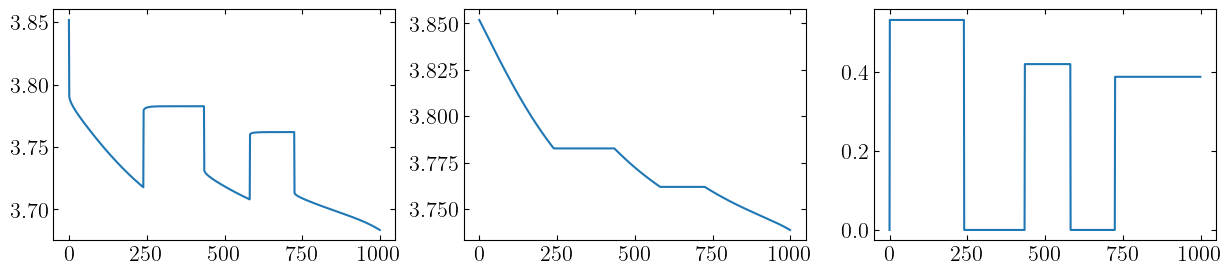

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(V_test[0, :], label='cn')
axes[1].plot(ocv_test[0, :], label='valid')
axes[2].plot(I_test[0, :], label='dI')


In [148]:
# Parameter identification via gradient descent
class BatteryPHNN_Constant(nn.Module):
    def __init__(self):
        super().__init__()
        # One set of parameters for the entire dataset
        self.r0_raw = nn.Parameter(torch.tensor(0.0))
        self.r1_raw = nn.Parameter(torch.tensor(0.0))
        self.c1_raw = nn.Parameter(torch.tensor(1.))
        self.r2_raw = nn.Parameter(torch.tensor(0.0))
        self.c2_raw = nn.Parameter(torch.tensor(1.))

    @property
    def R0(self): return nn.functional.relu(self.r0_raw)
    @property
    def R1(self): return nn.functional.relu(self.r1_raw)
    @property
    def C1(self): return nn.functional.relu(self.c1_raw)
    @property
    def R2(self): return nn.functional.relu(self.r2_raw)
    @property
    def C2(self): return nn.functional.relu(self.c2_raw)

model = BatteryPHNN_Constant()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def dynamics(ut,R,C, I_t, dt):

    dU = -ut / (R * C) + I_t / C 

    return dU * dt + ut 


def Euler_evolver(I, dt,ocv):
    '''
    x   : (B, 2)   [Q, q1]
    I_t : (B,)     current [A]
    dt  : float
    '''

    u10 = torch.zeros(I.shape[0], device=I.device)
    u20 = torch.zeros(I.shape[0], device=I.device)
    B_b, T_steps = I.shape
    V_pred = []
    R1 = model.R1
    C1 = model.C1
    R2 = model.R2
    C2 = model.C2

    for t in range(T_steps):
        I_t   = I[:, t]         # (B,)
        ocv_t = ocv[:, t]       # (B,)
        u1 = dynamics(u10,R1, C1, I_t,dt)  # (B, 2)
        u2 = dynamics(u20,R2,C2, I_t,dt)
        u10 = u1; u20 = u2

        V_t = ocv_t - (u1 + u2) - model.R0 * I_t  # (B,)     Compute voltage from OCV and q1
        V_pred.append(V_t)

    # for B in range(B_b):
    #     U = ECM_solve([model.R0.item(), R1.item(), C1.item(), R2.item(), C2.item()], I[B].cpu().numpy(), t_fixed)
    #     V_pred.append(torch.tensor(U, device=I.device) - ocv[B])
    
   
    return torch.stack(V_pred, dim=1)  # (B, T)



def masked_mse(pred, target, mask):
    err = (pred - target) ** 2    # (B, T)
    return (err * mask).sum() / (mask.sum() * 2)

def mse(pred, target):
    return ((pred - target) ** 2).mean()
def training(epochs=10):
    history = {"loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        start_t = time.perf_counter()

        for x_b, y_b, mask_b in train_loader_batch:
            B_b = x_b.shape[0]
            
            V_pred = Euler_evolver(x_b[:,:,0], DT, x_b[:,:,1])
            V_true = y_b[:,:,0]  # (B, T

            loss = mse(V_pred, V_true)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tot_ep_loss += loss.item()

        avg_loss = tot_ep_loss / len(train_loader_batch)  # Average loss per batch
        end_t = time.perf_counter()

        history["loss"].append(avg_loss)
        #history["p_loss"].append(p_last)

        history["time per ep"].append(end_t - start_t)
        print(f"Epoch {ep+1} | loss {avg_loss:.3e} | time {end_t - start_t:.2f}s")

    return history


In [149]:
history = training(epochs=30)

Epoch 1 | loss nan | time 0.69s
Epoch 2 | loss nan | time 0.72s
Epoch 3 | loss nan | time 0.69s
Epoch 4 | loss nan | time 0.60s
Epoch 5 | loss nan | time 0.60s
Epoch 6 | loss nan | time 0.63s


KeyboardInterrupt: 

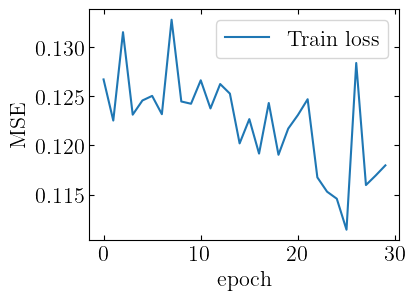

In [ ]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend();

Learned parameters:
R0=0.1881
R1=0.1381
C1=100.0110
R2=0.4881
C2=100.0118


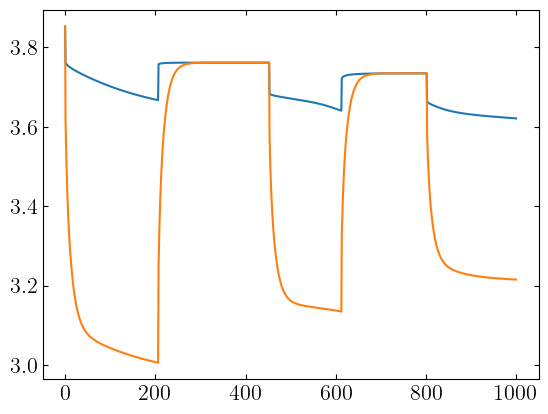

In [ ]:
V_pred_train = Euler_evolver(x_train_batch[:,:,0], DT, x_train_batch[:,:,1])
V_pred_test = Euler_evolver(x_test_batch[:,:,0], DT, x_test_batch[:,:,1])

plt.plot(V_train[0, :], label='V true')
plt.plot(V_pred_train[0, :].detach().numpy(), label='V pred train')

print(f"Learned parameters:\nR0={model.R0.item():.4f}\nR1={model.R1.item():.4f}\nC1={model.C1.item():.4f}\nR2={model.R2.item():.4f}\nC2={model.C2.item():.4f}")


In [ ]:
from scipy.interpolate import interp1d
def ECM_solve(theta, i, t):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C

    # Solve ODE
    U1 = scipy.integrate.odeint(dU, 0.0, t, args=(theta[1],theta[2])).flatten()
    U2 = scipy.integrate.odeint(dU, 0.0, t, args=(theta[3],theta[4])).flatten()
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model = (- i * theta[0] - U)

    return eta_model

In [ ]:
idx = 0
V_pred, V_true, I_phys,t_plot, valid = eval_rollout_phnn(idx)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))

axes[0].plot(t_plot[valid], V_true[valid], '--', color = 'tab:red', label=r'True $V_t$')
axes[0].plot(t_plot[valid], V_pred[valid], color = 'tab:blue',  label=r'Predicted $V_t$')
axes[0].plot(t_plot, ocv_test[idx][valid], 'k-', label=r'OCV')
ecm_sol = ECM_solve([model.R0.item(), model.R1.item(), model.C1.item(), model.R2.item(), model.C2.item()], I_phys.ravel(),t_plot.ravel())
axes[0].plot(t_plot[valid].ravel(), ecm_sol[valid] + ocv_test[idx][valid], 'g-', label=r'ECM Voltage')
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Voltage [V]")
axes[0].legend()

#print(model.R0.item(), model.R1.item(), model.C1.item(), model.R2.item(), model.C2.item())

axes[3].plot(t_plot, I_phys[0, :], color='tab:purple', label=r'RC time constant $\tau$ [s]')
axes[3].set_xlabel("Time [s]")

fig.tight_layout()
print(f"Learned parameters: R0={model.R0.item():.4f}\nR1={model.R1.item():.4f}\nC1={model.C1.item():.4f}\nR2={model.R2.item():.4f}\nC2={model.C2.item():.4f}")

IndexError: index 1 is out of bounds for dimension 2 with size 1